In [10]:
import os
import re
import sys
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

sys.path.insert(0, "/scratch/elena/9Li/scripts")

import geometry_wcte
import functions_multilateration

# -----------------------------------------
# Plot style
# -----------------------------------------

rcParams["mathtext.fontset"] = "stix"
rcParams["font.family"] = "STIXGeneral"

rcParams["figure.figsize"] = [16, 6]

rcParams["font.size"] = 22
rcParams["axes.labelsize"] = 20
rcParams["axes.titlesize"] = 20
rcParams["legend.fontsize"] = 16
rcParams["xtick.labelsize"] = 12
rcParams["ytick.labelsize"] = 16


# ==============================================================================
# Choose run (AmBe)
# ==============================================================================

run_number = 2508
processed_folder = f"/scratch/elena/9Li/results/run{run_number}/processed"

print(f"Run {run_number} (AmBe)")
print(f"Folder: {processed_folder}")

# ==============================================================================
# Read all pickle files (including subfolders like FV_1/)
# ==============================================================================

all_files = sorted(glob(f"{processed_folder}/**/*.pkl", recursive=True))

# ==============================================================================
# Helper function
# ==============================================================================

def load_dataframe(file_list, label):

    if len(file_list) == 0:
        print(f"{label:<15}:   0 files")
        return pd.DataFrame()

    df = pd.concat(
        [pd.read_pickle(f) for f in file_list],
        ignore_index=True
    )

    print(f"{label:<15}: {len(file_list):2d} files   ({len(df):8,d} clusters)")

    return df


# ==============================================================================
# STAGE 1: Sliding windows
# ==============================================================================

stage1_files = sorted([
    f for f in all_files
    if "Li9_clusters_chunk_" in os.path.basename(f)
    and "_multilat" not in f
    and "Refine_" not in f
    and "Final_FV_" not in f
])

# ==============================================================================
# STAGE 2: Multilateration
# ==============================================================================

stage2_files = sorted([
    f for f in all_files
    if "_multilat.pkl" in f
])

# ==============================================================================
# STAGE 4: Refinement
# ==============================================================================

stage4_files = sorted([
    f for f in all_files
    if "Refine_Li9_clusters" in f
])

# ==============================================================================
# STAGE 5: Final FV
# ==============================================================================

stage5_files = sorted([
    f for f in all_files
    if "Final_FV_" in f
])


# ==============================================================================
# Load DataFrames
# ==============================================================================

df_stage1 = load_dataframe(stage1_files, "Stage 1")
df_stage2 = load_dataframe(stage2_files, "Stage 2")
df_stage4 = load_dataframe(stage4_files, "Stage 4")
df_stage5 = load_dataframe(stage5_files, "Stage 5")

print(f"\nAll DataFrames loaded successfully for run{run_number}")

Run 2508 (AmBe)
Folder: /scratch/elena/9Li/results/run2508/processed
Stage 1        :  2 files   (      16 clusters)
Stage 2        :  2 files   (      16 clusters)
Stage 4        :  2 files   (       2 clusters)
Stage 5        :  1 files   (       0 clusters)

All DataFrames loaded successfully for run2508


Stage 2: Multilateration: 0 clusters plotted
Stage 4: Refinement: 0 clusters plotted
Stage 5: Final FV: 0 clusters plotted


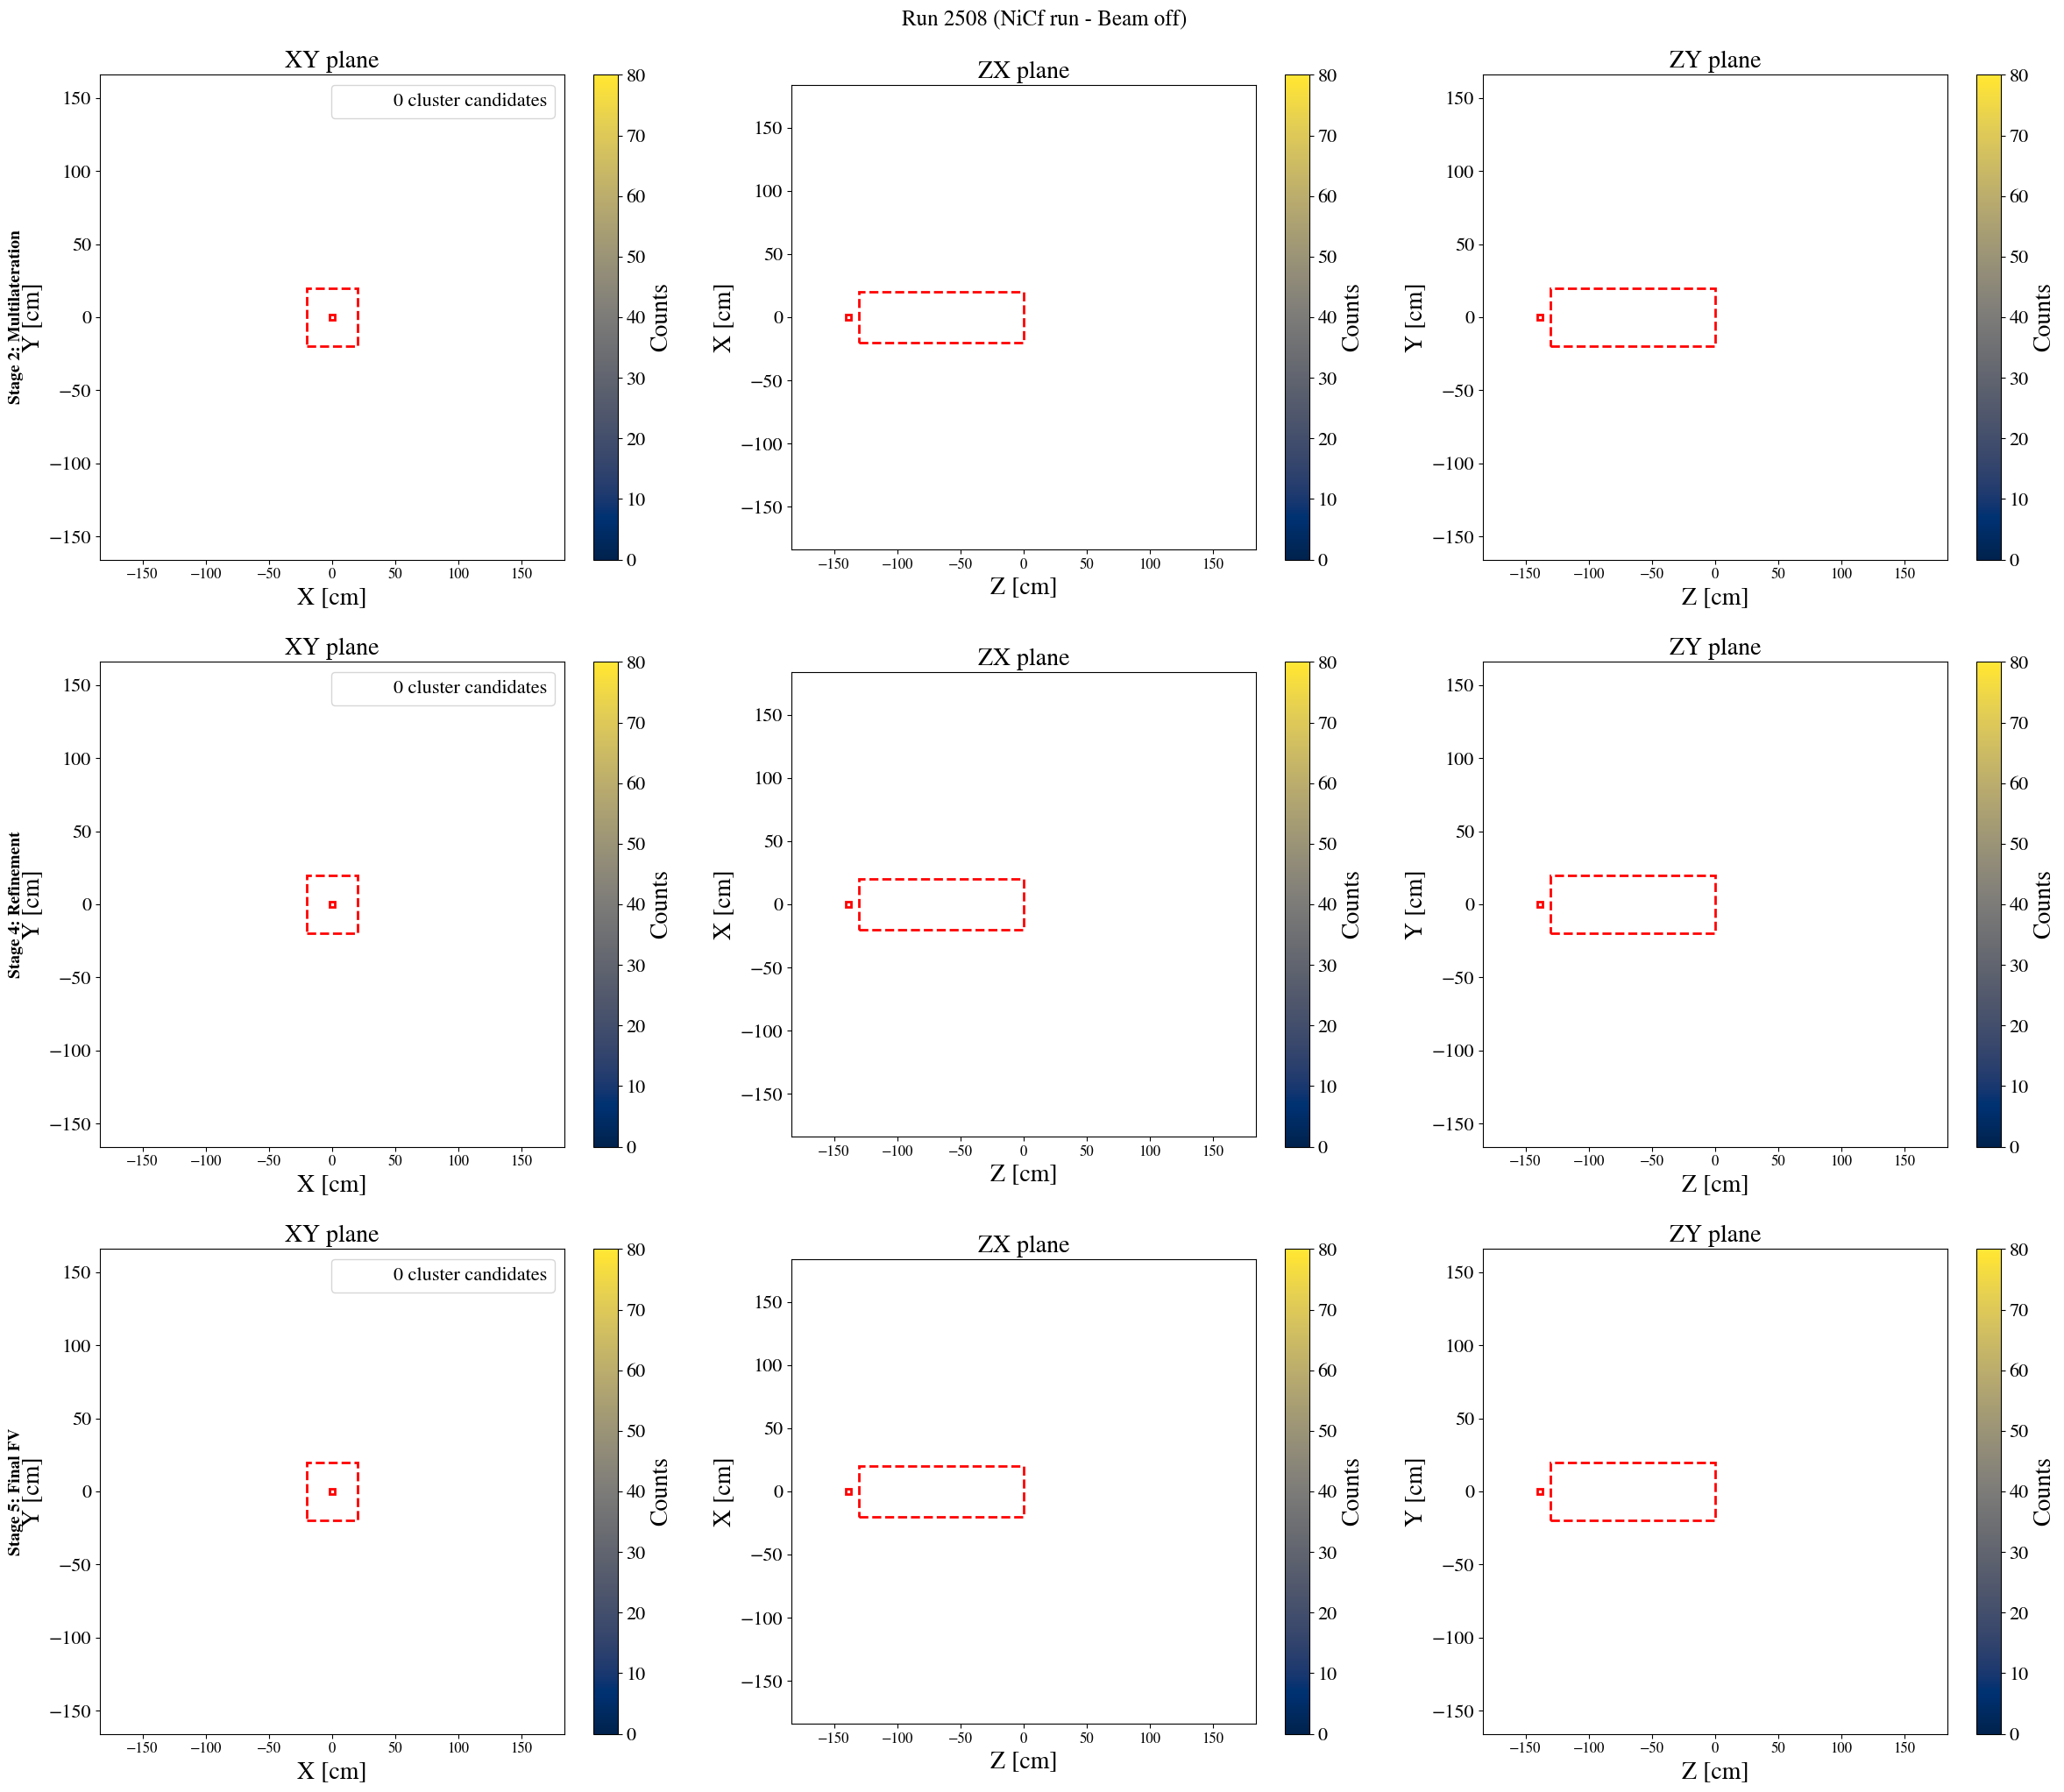

In [11]:
def plot_vertex_maps_all_stages(df_stage2, df_stage4, df_stage5):

    dfs = [
        (df_stage2, "Stage 2: Multilateration"),
        (df_stage4, "Stage 4: Refinement"),
        (df_stage5, "Stage 5: Final FV"),
    ]

    fig, axs = plt.subplots(3, 3, figsize=(24, 21))

    beam_pipe = [0.0, 0.0, -138.7963]
    beam_halfwidth = 2.0  # cm -> beam window = 4 cm diameter

    bins = 40
    vmax = 80

    R = 153.7963  # cm
    H = 271.4235  # cm

    # Fiducial Volume
    x_lims = [-20.0, 20.0]
    y_lims = [-20.0, 20.0]
    z_lims = [-130.0, 0.0]

    for row, (df, stage_name) in enumerate(dfs):

        # -------------------------------------------------
        # Determine vertex column names
        # -------------------------------------------------
        if {"v_x_fine", "v_y_fine", "v_z_fine"}.issubset(df.columns):
            xcol = "v_x_fine"
            ycol = "v_y_fine"
            zcol = "v_z_fine"
        else:
            xcol = "vertex_x"
            ycol = "vertex_y"
            zcol = "vertex_z"

        # -------------------------------------------------
        # Fiducial / quality selection
        # -------------------------------------------------
        mask = (
            df.fit_success
            & (df.chi2_ndof < 3)
            & (df[xcol] ** 2 + df[zcol] ** 2 <= R**2)
            & (np.abs(df[ycol]) <= H / 2)
        )

        df_clean = df.loc[mask]
        n_clusters = len(df_clean)

        print(f"{stage_name}: {n_clusters} clusters plotted")

        # =================================================
        # XY Plane
        # =================================================
        im0 = axs[row, 0].hist2d(
            df_clean[xcol],
            df_clean[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row, 0].set_xlim(-R - 30, R + 30)
        axs[row, 0].set_ylim(-H / 2 - 30, H / 2 + 30)
        axs[row, 0].set_aspect("auto")

        # Beam pipe
        axs[row, 0].add_patch(
            Rectangle(
                (
                    beam_pipe[0] - beam_halfwidth,
                    beam_pipe[1] - beam_halfwidth
                ),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        # Fiducial Volume
        axs[row, 0].add_patch(
            Rectangle(
                (x_lims[0], y_lims[0]),
                x_lims[1] - x_lims[0],
                y_lims[1] - y_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row, 0].set_title("XY plane")
        axs[row, 0].set_xlabel("X [cm]")
        axs[row, 0].set_ylabel("Y [cm]")

        dummy = Line2D(
            [],
            [],
            linestyle="",
            label=f"{n_clusters} cluster candidates"
        )

        axs[row, 0].legend(
            handles=[dummy],
            loc="upper right",
            frameon=True
        )

        plt.colorbar(
            im0[3],
            ax=axs[row, 0],
            label="Counts"
        )

        # =================================================
        # ZX Plane
        # =================================================
        im1 = axs[row, 1].hist2d(
            df_clean[zcol],
            df_clean[xcol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row, 1].set_xlim(-R - 30, R + 30)
        axs[row, 1].set_ylim(-R - 30, R + 30)
        axs[row, 1].set_aspect("equal")

        # Beam pipe
        axs[row, 1].add_patch(
            Rectangle(
                (
                    beam_pipe[2] - beam_halfwidth,
                    beam_pipe[0] - beam_halfwidth
                ),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        # Fiducial Volume
        axs[row, 1].add_patch(
            Rectangle(
                (z_lims[0], x_lims[0]),
                z_lims[1] - z_lims[0],
                x_lims[1] - x_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row, 1].set_title("ZX plane")
        axs[row, 1].set_xlabel("Z [cm]")
        axs[row, 1].set_ylabel("X [cm]")

        plt.colorbar(
            im1[3],
            ax=axs[row, 1],
            label="Counts"
        )

        # =================================================
        # ZY Plane
        # =================================================
        im2 = axs[row, 2].hist2d(
            df_clean[zcol],
            df_clean[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row, 2].set_xlim(-R - 30, R + 30)
        axs[row, 2].set_ylim(-H / 2 - 30, H / 2 + 30)
        axs[row, 2].set_aspect("auto")

        # Beam pipe
        axs[row, 2].add_patch(
            Rectangle(
                (
                    beam_pipe[2] - beam_halfwidth,
                    beam_pipe[1] - beam_halfwidth
                ),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        # Fiducial Volume
        axs[row, 2].add_patch(
            Rectangle(
                (z_lims[0], y_lims[0]),
                z_lims[1] - z_lims[0],
                y_lims[1] - y_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row, 2].set_title("ZY plane")
        axs[row, 2].set_xlabel("Z [cm]")
        axs[row, 2].set_ylabel("Y [cm]")

        plt.colorbar(
            im2[3],
            ax=axs[row, 2],
            label="Counts"
        )

        # -------------------------------------------------
        # Stage title on the left of each row
        # -------------------------------------------------
        axs[row, 0].text(
            -0.18,
            0.5,
            stage_name,
            transform=axs[row, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=14,
            fontweight="bold",
        )

    # =====================================================
    # Global title
    # =====================================================
    fig.suptitle(
        f"Run {run_number} (NiCf run - Beam off)",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()


# =====================================================
# Call
# =====================================================
plot_vertex_maps_all_stages(
    df_stage2,
    df_stage4,
    df_stage5
)

### para los runs de Li9

In [16]:
import os
import re
import sys
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

sys.path.insert(0, "/scratch/elena/9Li/scripts")

import geometry_wcte
import functions_multilateration

# -----------------------------------------
# Plot style
# -----------------------------------------

rcParams["mathtext.fontset"] = "stix"
rcParams["font.family"] = "STIXGeneral"

rcParams["figure.figsize"] = [16, 6]

rcParams["font.size"] = 22
rcParams["axes.labelsize"] = 20
rcParams["axes.titlesize"] = 20
rcParams["legend.fontsize"] = 16
rcParams["xtick.labelsize"] = 12
rcParams["ytick.labelsize"] = 16


# ==============================================================================
# Choose run
# ==============================================================================

run_number = 1848
processed_folder = f"/scratch/elena/9Li/results/run{run_number}/processed"

print(f"Run {run_number}")
print(f"Folder: {processed_folder}")

# ==============================================================================
# Read all pickle files in root processed folder
# ==============================================================================

all_files = sorted(glob(f"{processed_folder}/*.pkl"))

# ==============================================================================
# Helper function
# ==============================================================================

def load_dataframe(file_list, label):

    if len(file_list) == 0:
        print(f"{label:<15}:   0 files")
        return pd.DataFrame()

    df = pd.concat(
        [pd.read_pickle(f) for f in file_list],
        ignore_index=True
    )

    print(f"{label:<15}: {len(file_list):2d} files   ({len(df):8,d} clusters)")

    return df


# ==============================================================================
# STAGE 1: Sliding windows
# ==============================================================================

stage1_sig_files = sorted([
    f for f in all_files
    if "Li9_clusters_chunk_" in f
    and "_multilat" not in f
    and "Refine_" not in f
    and "Final_FV_" not in f
    and "_BKG" not in f
])

stage1_bkg_files = sorted([
    f for f in all_files
    if "Li9_clusters_chunk_" in f
    and "_multilat" not in f
    and "Refine_" not in f
    and "Final_FV_" not in f
    and "_BKG" in f
])


# ==============================================================================
# STAGE 2: Multilateration
# ==============================================================================

stage2_sig_files = sorted([
    f for f in all_files
    if "_multilat.pkl" in f
    and "_BKG" not in f
])

stage2_bkg_files = sorted([
    f for f in all_files
    if "_BKG_multilat.pkl" in f
])


# ==============================================================================
# STAGE 4: Refinement
# ==============================================================================

stage4_sig_files = sorted([
    f for f in all_files
    if "Refine_Li9_clusters" in f
    and "_BKG" not in f
])

stage4_bkg_files = sorted([
    f for f in all_files
    if "Refine_Li9_clusters" in f
    and "_BKG" in f
])


# ==============================================================================
# STAGE 5: Final FV
# ==============================================================================

stage5_sig_files = sorted([
    f for f in all_files
    if "Final_FV_" in f
    and "_BKG" not in f
])

stage5_bkg_files = sorted([
    f for f in all_files
    if "Final_FV_" in f
    and "_BKG" in f
])


# ==============================================================================
# Load all DataFrames
# ==============================================================================

df_stage1_sig = load_dataframe(stage1_sig_files, "Stage 1 SIG")
df_stage1_bkg = load_dataframe(stage1_bkg_files, "Stage 1 BKG")

df_stage2_sig = load_dataframe(stage2_sig_files, "Stage 2 SIG")
df_stage2_bkg = load_dataframe(stage2_bkg_files, "Stage 2 BKG")

df_stage4_sig = load_dataframe(stage4_sig_files, "Stage 4 SIG")
df_stage4_bkg = load_dataframe(stage4_bkg_files, "Stage 4 BKG")

df_stage5_sig = load_dataframe(stage5_sig_files, "Stage 5 SIG")
df_stage5_bkg = load_dataframe(stage5_bkg_files, "Stage 5 BKG")

print(f"\nAll DataFrames loaded successfully for run{run_number}")

Run 1848
Folder: /scratch/elena/9Li/results/run1848/processed


Stage 1 SIG    : 31 files   ( 171,894 clusters)
Stage 1 BKG    : 16 files   (  86,449 clusters)
Stage 2 SIG    : 31 files   ( 171,894 clusters)
Stage 2 BKG    : 16 files   (  86,449 clusters)
Stage 4 SIG    : 31 files   (  49,908 clusters)
Stage 4 BKG    : 16 files   (  25,484 clusters)
Stage 5 SIG    :   0 files
Stage 5 BKG    :   0 files

All DataFrames loaded successfully for run1848


Stage 2: Multilateration - Signal: 8622 clusters


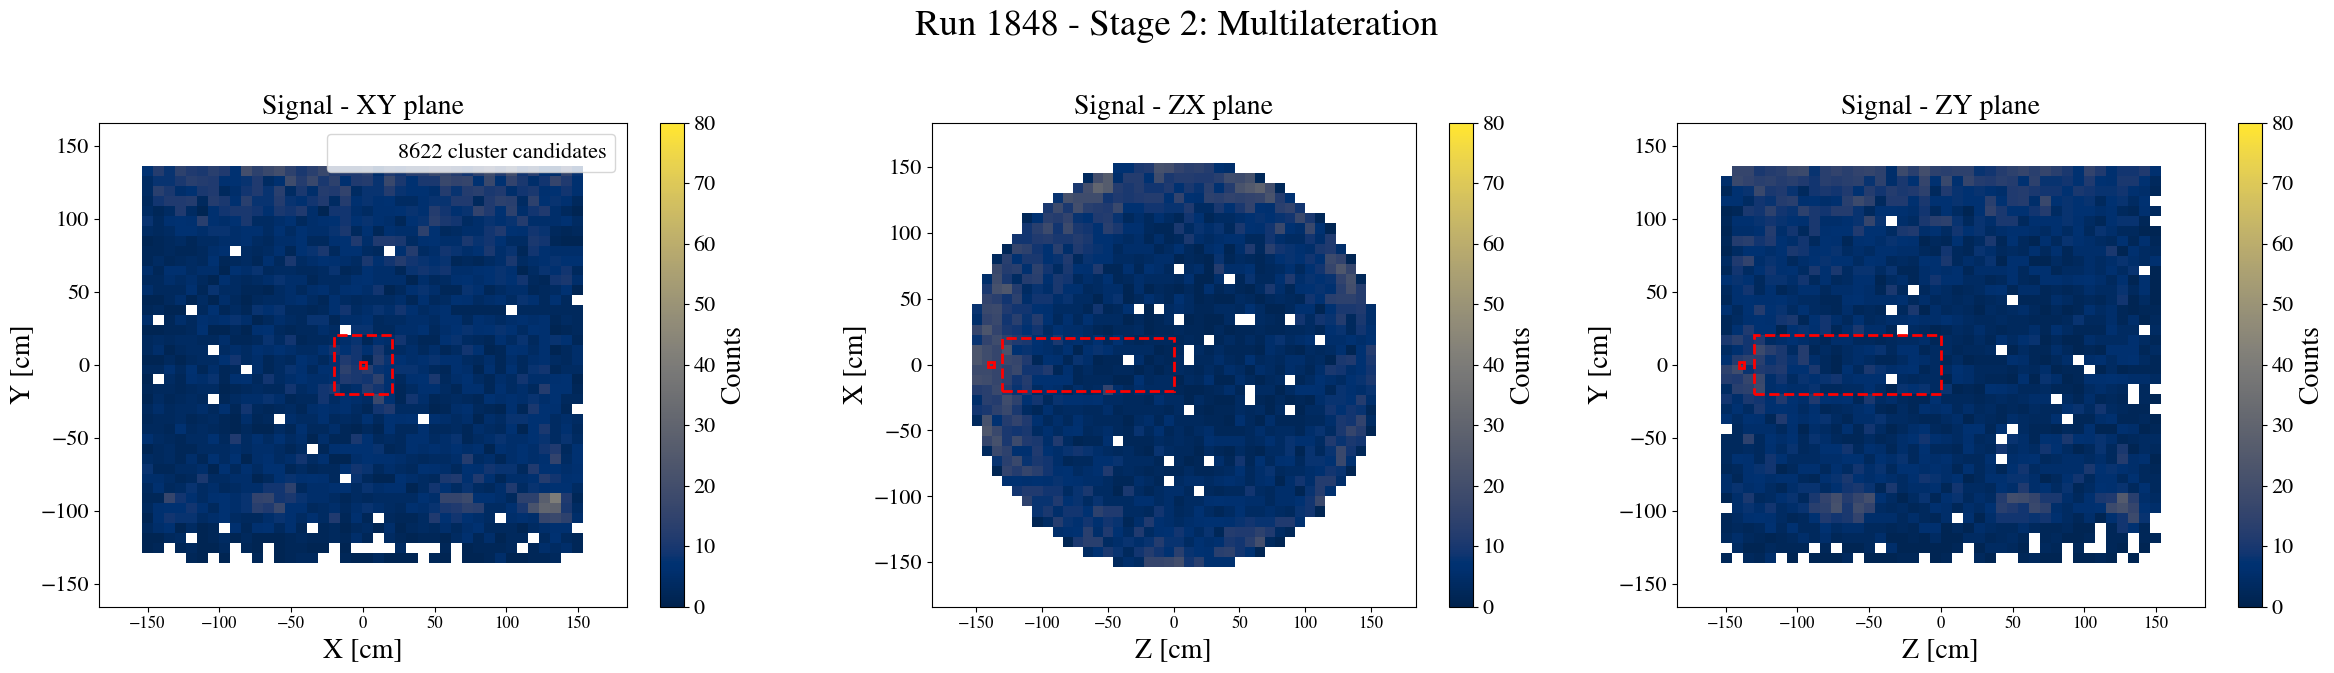

Stage 3: Refinement - Signal: 7923 clusters


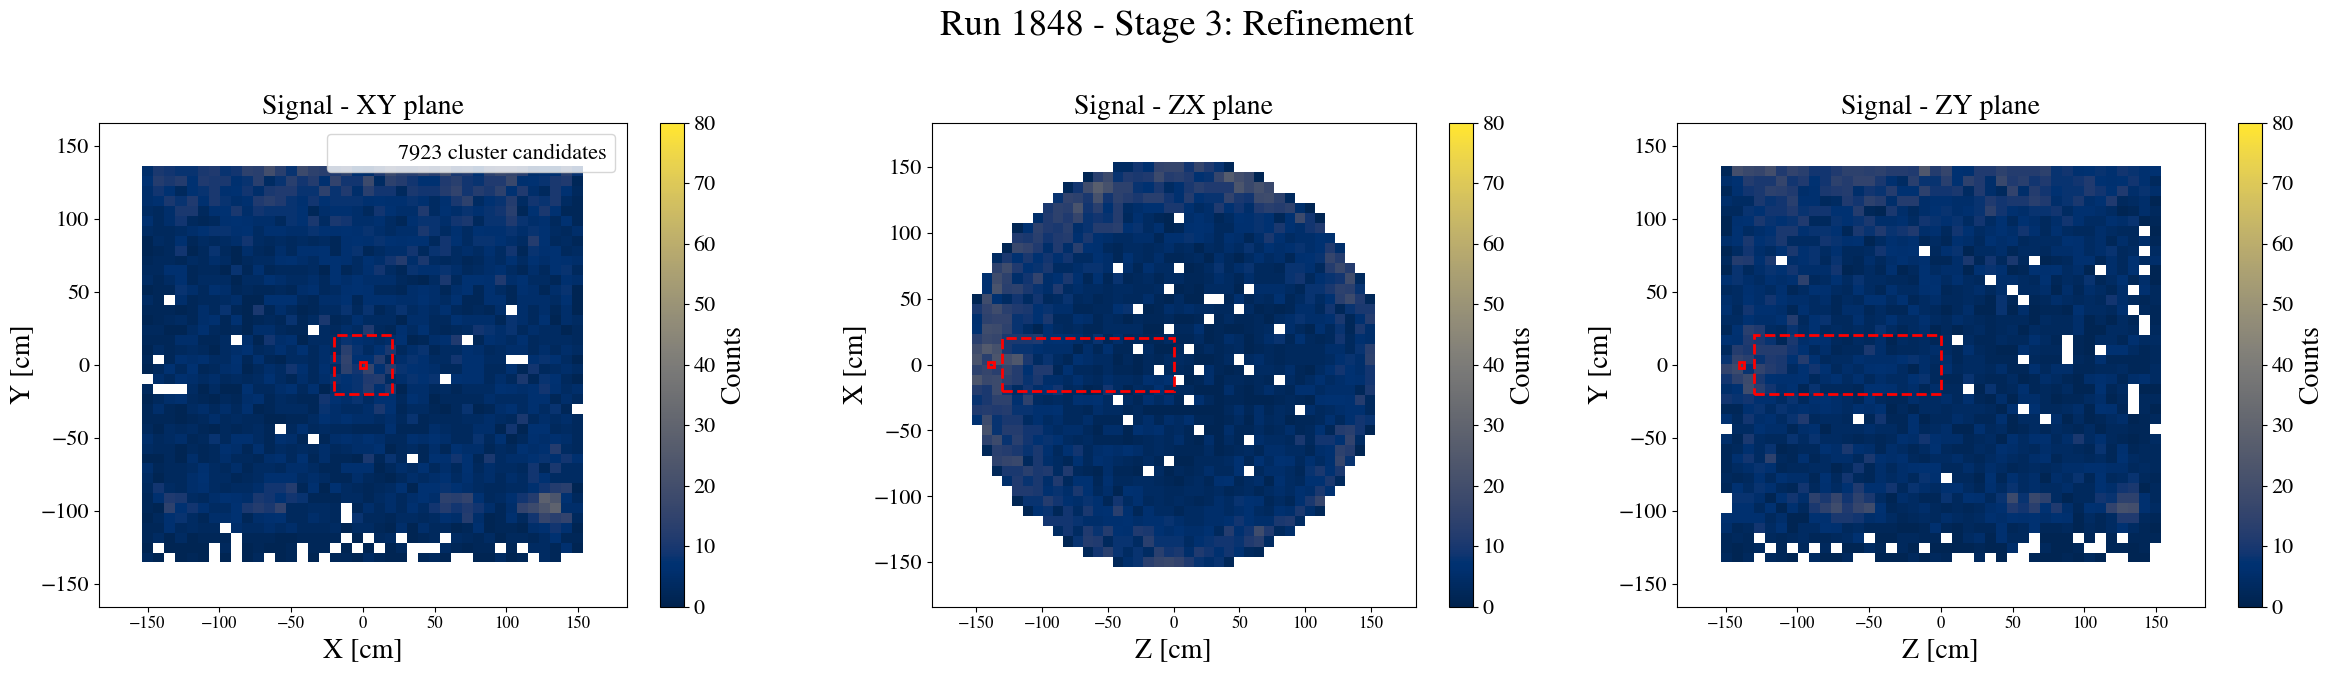

DataFrame for Stage 4: Final FV is empty. Skipping plot.


In [17]:
def plot_vertex_maps_signal_only(df_sig, stage_name):

    if df_sig.empty:
        print(f"DataFrame for {stage_name} is empty. Skipping plot.")
        return

    # Determinar columnas de vértices
    if {"v_x_fine", "v_y_fine", "v_z_fine"}.issubset(df_sig.columns):
        xcol, ycol, zcol = "v_x_fine", "v_y_fine", "v_z_fine"
    else:
        xcol, ycol, zcol = "vertex_x", "vertex_y", "vertex_z"

    beam_pipe = [0.0, 0.0, -138.7963]
    beam_halfwidth = 2.0  # cm -> beam window = 4 cm diameter

    bins = 40
    vmax = 80

    R = 153.7963
    H = 271.4235

    # Fiducial Volume
    x_lims = [-20.0, 20.0]
    y_lims = [-20.0, 20.0]
    z_lims = [-130.0, 0.0]

    mask = (
        df_sig.fit_success
        & (df_sig.chi2_ndof < 3)
        & (df_sig[xcol] ** 2 + df_sig[zcol] ** 2 <= R**2)
        & (np.abs(df_sig[ycol]) <= H / 2)
    )

    df_clean = df_sig.loc[mask]
    n_clusters = len(df_clean)

    print(f"{stage_name} - Signal: {n_clusters} clusters")

    fig, axs = plt.subplots(1, 3, figsize=(24, 7))

    # =====================================================
    # XY Plane
    # =====================================================
    im0 = axs[0].hist2d(
        df_clean[xcol],
        df_clean[ycol],
        bins=bins,
        cmap="cividis",
        cmin=1,
        vmin=0,
        vmax=vmax,
    )

    axs[0].set_xlim(-R - 30, R + 30)
    axs[0].set_ylim(-H / 2 - 30, H / 2 + 30)
    axs[0].set_aspect("auto")

    # Beam pipe & Fiducial Volume
    axs[0].add_patch(
        Rectangle(
            (beam_pipe[0] - beam_halfwidth, beam_pipe[1] - beam_halfwidth),
            4, 4, facecolor="none", edgecolor="red", linewidth=2
        )
    )
    axs[0].add_patch(
        Rectangle(
            (x_lims[0], y_lims[0]),
            x_lims[1] - x_lims[0], y_lims[1] - y_lims[0],
            facecolor="none", edgecolor="red", linestyle="--", linewidth=2
        )
    )

    axs[0].set_title("Signal - XY plane")
    axs[0].set_xlabel("X [cm]")
    axs[0].set_ylabel("Y [cm]")

    dummy = Line2D([], [], linestyle="", label=f"{n_clusters} cluster candidates")
    axs[0].legend(handles=[dummy], loc="upper right", frameon=True)
    plt.colorbar(im0[3], ax=axs[0], label="Counts")

    # =====================================================
    # ZX Plane
    # =====================================================
    im1 = axs[1].hist2d(
        df_clean[zcol],
        df_clean[xcol],
        bins=bins,
        cmap="cividis",
        cmin=1,
        vmin=0,
        vmax=vmax,
    )

    axs[1].set_xlim(-R - 30, R + 30)
    axs[1].set_ylim(-R - 30, R + 30)
    axs[1].set_aspect("equal")

    # Beam pipe & Fiducial Volume
    axs[1].add_patch(
        Rectangle(
            (beam_pipe[2] - beam_halfwidth, beam_pipe[0] - beam_halfwidth),
            4, 4, facecolor="none", edgecolor="red", linewidth=2
        )
    )
    axs[1].add_patch(
        Rectangle(
            (z_lims[0], x_lims[0]),
            z_lims[1] - z_lims[0], x_lims[1] - x_lims[0],
            facecolor="none", edgecolor="red", linestyle="--", linewidth=2
        )
    )

    axs[1].set_title("Signal - ZX plane")
    axs[1].set_xlabel("Z [cm]")
    axs[1].set_ylabel("X [cm]")
    plt.colorbar(im1[3], ax=axs[1], label="Counts")

    # =====================================================
    # ZY Plane
    # =====================================================
    im2 = axs[2].hist2d(
        df_clean[zcol],
        df_clean[ycol],
        bins=bins,
        cmap="cividis",
        cmin=1,
        vmin=0,
        vmax=vmax,
    )

    axs[2].set_xlim(-R - 30, R + 30)
    axs[2].set_ylim(-H / 2 - 30, H / 2 + 30)
    axs[2].set_aspect("auto")

    # Beam pipe & Fiducial Volume
    axs[2].add_patch(
        Rectangle(
            (beam_pipe[2] - beam_halfwidth, beam_pipe[1] - beam_halfwidth),
            4, 4, facecolor="none", edgecolor="red", linewidth=2
        )
    )
    axs[2].add_patch(
        Rectangle(
            (z_lims[0], y_lims[0]),
            z_lims[1] - z_lims[0], y_lims[1] - y_lims[0],
            facecolor="none", edgecolor="red", linestyle="--", linewidth=2
        )
    )

    axs[2].set_title("Signal - ZY plane")
    axs[2].set_xlabel("Z [cm]")
    axs[2].set_ylabel("Y [cm]")
    plt.colorbar(im2[3], ax=axs[2], label="Counts")

    plt.suptitle(f"Run {run_number} - {stage_name}")
    plt.tight_layout()
    plt.show()


# =====================================================
# Call plots (Solo Signal)
# =====================================================
plot_vertex_maps_signal_only(df_stage2_sig, "Stage 2: Multilateration")
plot_vertex_maps_signal_only(df_stage4_sig, "Stage 3: Refinement")
plot_vertex_maps_signal_only(df_stage5_sig, "Stage 4: Final FV")